# Logistic Regression

## Learning objective

This notebook covers **logistic regression** for binary classification. It
models the probability of the positive class with a linear score passed through
the sigmoid function, and it is trained by minimizing the binary cross-entropy
loss with gradient descent. You should finish able to:

- describe how a linear decision boundary and the sigmoid combine to produce
  class probabilities,
- implement the sigmoid, the binary cross-entropy loss, the gradient-descent
  update, `predict_proba`, and `predict` from scratch (with an intercept term),
- train the model on a small synthetic dataset and read its loss curve, and
- discuss the role of the decision threshold, the learning rate, and feature
  scaling.

## The mathematical idea

Each example is a feature vector $\mathbf{x} \in \mathbb{R}^d$ with a binary
label $y \in \{0, 1\}$. Logistic regression forms a linear score

$$
z = \mathbf{w}^\top \mathbf{x} + b,
$$

where $\mathbf{w}$ are the weights and $b$ is the **intercept** (bias). The
score is mapped to a probability with the **sigmoid** function

$$
\sigma(z) = \frac{1}{1 + e^{-z}} \in (0, 1),
$$

so $\hat{p} = \sigma(z)$ is the model's estimate of $P(y = 1 \mid \mathbf{x})$.
The set of points where $z = 0$ (equivalently $\hat{p} = 0.5$) is the **linear
decision boundary**.

We fit the parameters by minimizing the **binary cross-entropy** (log loss)
over $n$ examples,

$$
L = -\frac{1}{n} \sum_{i=1}^{n}
\Big[ y_i \log \hat{p}_i + (1 - y_i) \log (1 - \hat{p}_i) \Big].
$$

A convenient property of this loss with the sigmoid is that its gradients take
a simple form. With $\hat{\mathbf{p}} = \sigma(X\mathbf{w} + b)$,

$$
\frac{\partial L}{\partial \mathbf{w}} = \frac{1}{n} X^\top (\hat{\mathbf{p}} - \mathbf{y}),
\qquad
\frac{\partial L}{\partial b} = \frac{1}{n} \sum_{i=1}^{n} (\hat{p}_i - y_i).
$$

**Gradient descent** then repeatedly steps the parameters in the direction that
decreases the loss, using a learning rate $\eta$:

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial L}{\partial \mathbf{w}},
\qquad
b \leftarrow b - \eta \frac{\partial L}{\partial b}.
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)

## A reproducible synthetic dataset

We generate a small two-dimensional, two-class dataset as two Gaussian blobs
with different centers. Because the classes are mostly (but not perfectly)
separable, a linear boundary should work well while still making a few mistakes,
which keeps the metrics interesting.

In [2]:
n_per_class = 100

mean_neg = np.array([-1.5, -1.0])
mean_pos = np.array([1.5, 1.0])
cov = np.array([[1.0, 0.3], [0.3, 1.0]])

X_neg = rng.multivariate_normal(mean_neg, cov, size=n_per_class)
X_pos = rng.multivariate_normal(mean_pos, cov, size=n_per_class)

X = np.vstack([X_neg, X_pos])
y = np.concatenate([np.zeros(n_per_class), np.ones(n_per_class)])

# Shuffle so the two classes are interleaved.
perm = rng.permutation(X.shape[0])
X, y = X[perm], y[perm]

print('Feature matrix shape:', X.shape)
print('Label distribution:', {0: int((y == 0).sum()), 1: int((y == 1).sum())})

Feature matrix shape: (200, 2)
Label distribution: {0: 100, 1: 100}


## Feature scaling

Gradient descent behaves best when the features are on comparable scales, so we
standardize each column to zero mean and unit variance. The statistics are
computed once on this dataset for the demonstration; in a real workflow they
would be estimated on the training split only and then applied to the test
split. We keep the scaled data for training and plotting.

In [3]:
feature_mean = X.mean(axis=0)
feature_std = X.std(axis=0)
X_scaled = (X - feature_mean) / feature_std

print('Means after scaling:', np.round(X_scaled.mean(axis=0), 6))
print('Stds after scaling :', np.round(X_scaled.std(axis=0), 6))

Means after scaling: [ 0. -0.]
Stds after scaling : [1. 1.]


## Logistic regression from scratch

The class below implements everything we need: the sigmoid, the binary
cross-entropy loss, the gradient-descent training loop, `predict_proba` (class
probabilities), and `predict` (hard labels via a threshold). The intercept is
stored separately as `intercept_` and updated with its own gradient. We clip
the probabilities inside the loss to avoid taking the logarithm of zero.

In [4]:
class LogisticRegressionScratch:
    """Logistic regression trained with full-batch gradient descent."""

    def __init__(self, learning_rate=0.1, n_iterations=2000):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    @staticmethod
    def _sigmoid(z):
        # Numerically stable sigmoid.
        return np.where(z >= 0, 1 / (1 + np.exp(-z)), np.exp(z) / (1 + np.exp(z)))

    @staticmethod
    def _bce_loss(y_true, p_pred):
        eps = 1e-12
        p = np.clip(p_pred, eps, 1 - eps)
        return -np.mean(y_true * np.log(p) + (1 - y_true) * np.log(1 - p))

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        n_samples, n_features = X.shape

        self.coef_ = np.zeros(n_features)
        self.intercept_ = 0.0
        self.loss_history_ = []

        for _ in range(self.n_iterations):
            z = X @ self.coef_ + self.intercept_
            p = self._sigmoid(z)
            error = p - y

            grad_w = (X.T @ error) / n_samples
            grad_b = error.mean()

            self.coef_ -= self.learning_rate * grad_w
            self.intercept_ -= self.learning_rate * grad_b

            self.loss_history_.append(self._bce_loss(y, p))

        return self

    def predict_proba(self, X):
        X = np.asarray(X, dtype=float)
        return self._sigmoid(X @ self.coef_ + self.intercept_)

    def predict(self, X, threshold=0.5):
        return (self.predict_proba(X) >= threshold).astype(int)

## Train the model

We train on the standardized features and keep the loss at every iteration so
we can inspect convergence.

In [5]:
model = LogisticRegressionScratch(learning_rate=0.1, n_iterations=2000)
model.fit(X_scaled, y)

print('Learned intercept:', round(model.intercept_, 4))
print('Learned coefficients:', np.round(model.coef_, 4))
print('Final training loss:', round(model.loss_history_[-1], 4))

Learned intercept: 0.0967
Learned coefficients: [4.167  1.6333]
Final training loss: 0.142


## Loss history

The binary cross-entropy should decrease smoothly and then flatten as gradient
descent approaches a minimum. A curve that is still falling steeply at the end
would suggest training for more iterations or using a larger learning rate.

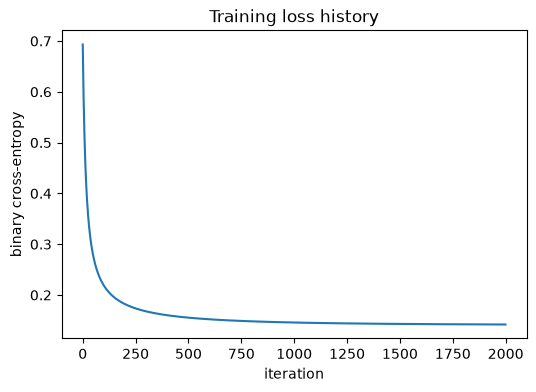

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(model.loss_history_)
ax.set_xlabel('iteration')
ax.set_ylabel('binary cross-entropy')
ax.set_title('Training loss history')
plt.show()

## Data and learned decision boundary

We plot the two classes and overlay the line where the predicted probability
equals 0.5. Points are colored by their true label using the default matplotlib
color cycle. A clean split with a few points on the wrong side is exactly what
we expect for overlapping Gaussian classes.

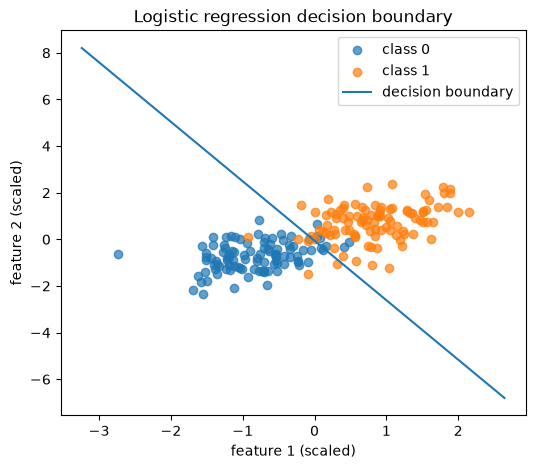

In [7]:
fig, ax = plt.subplots(figsize=(6, 5))

ax.scatter(X_scaled[y == 0, 0], X_scaled[y == 0, 1], label='class 0', alpha=0.7)
ax.scatter(X_scaled[y == 1, 0], X_scaled[y == 1, 1], label='class 1', alpha=0.7)

# Decision boundary: w0*x0 + w1*x1 + b = 0  ->  x1 = -(w0*x0 + b) / w1
x0_vals = np.linspace(X_scaled[:, 0].min() - 0.5, X_scaled[:, 0].max() + 0.5, 100)
w0, w1 = model.coef_
x1_vals = -(w0 * x0_vals + model.intercept_) / w1
ax.plot(x0_vals, x1_vals, label='decision boundary')

ax.set_xlabel('feature 1 (scaled)')
ax.set_ylabel('feature 2 (scaled)')
ax.set_title('Logistic regression decision boundary')
ax.legend()
plt.show()

## Evaluation metrics

We report accuracy, precision, recall, and F1 with small notebook-level helper
functions defined directly from the confusion-matrix counts, treating class 1
as the positive class.

In [8]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)


def precision_recall_f1(y_true, y_pred):
    tp = np.sum((y_pred == 1) & (y_true == 1))
    fp = np.sum((y_pred == 1) & (y_true == 0))
    fn = np.sum((y_pred == 0) & (y_true == 1))
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = (2 * precision * recall / (precision + recall)
          if (precision + recall) > 0 else 0.0)
    return precision, recall, f1


y_pred = model.predict(X_scaled)
prec, rec, f1 = precision_recall_f1(y, y_pred)

print('Accuracy :', round(accuracy(y, y_pred), 4))
print('Precision:', round(prec, 4))
print('Recall   :', round(rec, 4))
print('F1 score :', round(f1, 4))

Accuracy : 0.945
Precision: 0.9406
Recall   : 0.95
F1 score : 0.9453


## Interpretation

The learned line separates most of the two blobs, and the loss curve flattens,
indicating that gradient descent converged. Because the classes overlap, a
small number of points sit on the wrong side of the boundary, which is reflected
in the metrics being high but not perfect. The signs of the learned
coefficients tell us which direction in feature space pushes a point toward the
positive class.

## Threshold, learning rate, and feature scaling

- **Threshold.** `predict` labels a point positive when its probability is at
  least 0.5. Lowering the threshold catches more positives (higher recall, lower
  precision); raising it does the opposite. The threshold is a deployment choice
  and can be tuned separately from training.
- **Learning rate.** The step size $\eta$ controls convergence. Too small and
  training crawls; too large and the loss can oscillate or diverge. The smooth,
  flattening loss curve above suggests the chosen rate is reasonable here.
- **Feature scaling.** Standardizing the features puts the gradients on a
  similar scale across dimensions, which lets a single learning rate work well
  for every weight and generally speeds up convergence.

## Limitations and next steps

Logistic regression can only draw a **linear** boundary, so it underfits data
whose classes are separated by a curved surface. It can also overfit when there
are many correlated features and no regularization. Natural extensions are
**L2 (ridge) regularization** to stabilize the weights, **basis expansions** to
capture non-linearity, and a proper **train/test split** to estimate
generalization rather than evaluating on the training data as we did here for
simplicity.